

# Removing muscle ICA components



In [ ]:
!pip install mne

In [ ]:
!pip install python-picard

In [ ]:
import numpy as np
import mne

txt_file = "/content/Filt-Matias.txt"

# Saltar el encabezado
data = np.loadtxt(txt_file, skiprows=1)

# Transponer -> (2, n_muestras)
data = data.T

print(data.shape)

sfreq = 1000

# Completar hasta 64 canales
n_muestras = data.shape[1]

data64 = np.zeros((64, n_muestras))
data64[:2] = data

ch_names = ["Fp1", "Fp2"] + [f"EEG{i}" for i in range(3,65)]

info = mne.create_info(
    ch_names,
    sfreq,
    ch_types="eeg"
)

raw = mne.io.RawArray(data64, info)

montage = mne.channels.make_standard_montage("standard_1020")
raw.set_montage(montage, on_missing="ignore")

raw.filter(1, None)

print(raw)


(2, 117600)
Creating RawArray with float64 data, n_channels=64, n_times=117600
    Range : 0 ... 117599 =      0.000 ...   117.599 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 3301 samples (3.301 s)

<RawArray | 64 x 117600 (117.6 s), ~57.5 MiB, data loaded>


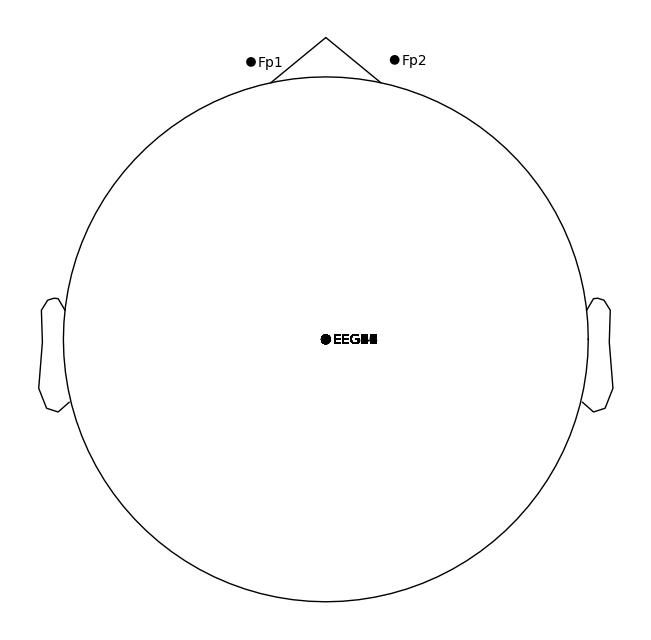

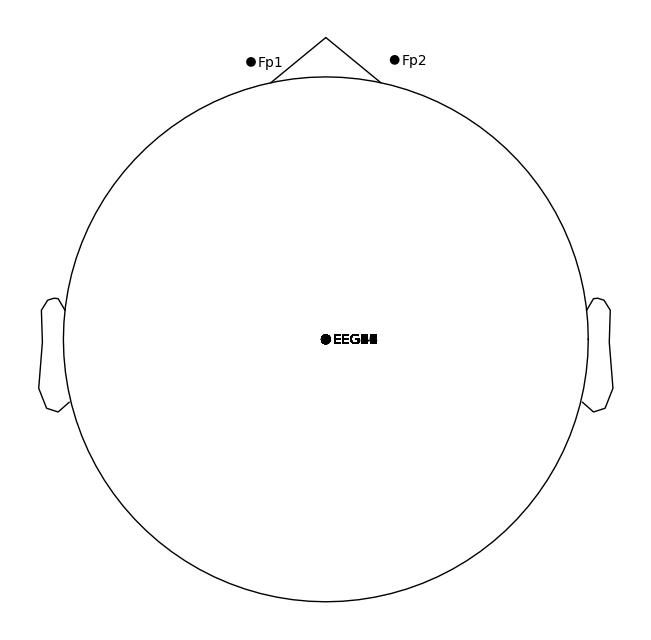

In [ ]:
# Verificar posiciones en este caso solo colocamos fp1 y fp2
raw.plot_sensors(show_names=True)

Run ICA



In [ ]:
ica = mne.preprocessing.ICA(
    n_components=2, method="picard", max_iter="auto", random_state=97
)
ica.fit(raw)

Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 2 components
Fitting ICA took 9.2s.


Method,picard
Fit parameters,max_iter=500
Fit,45 iterations on raw data (117600 samples)
ICA components,2
Available PCA components,64
Channel types,eeg
ICA components marked for exclusion,—


Remove components with postural muscle artifact using ICA



Creating RawArray with float64 data, n_channels=2, n_times=117600
    Range : 0 ... 117599 =      0.000 ...   117.599 secs
Ready.


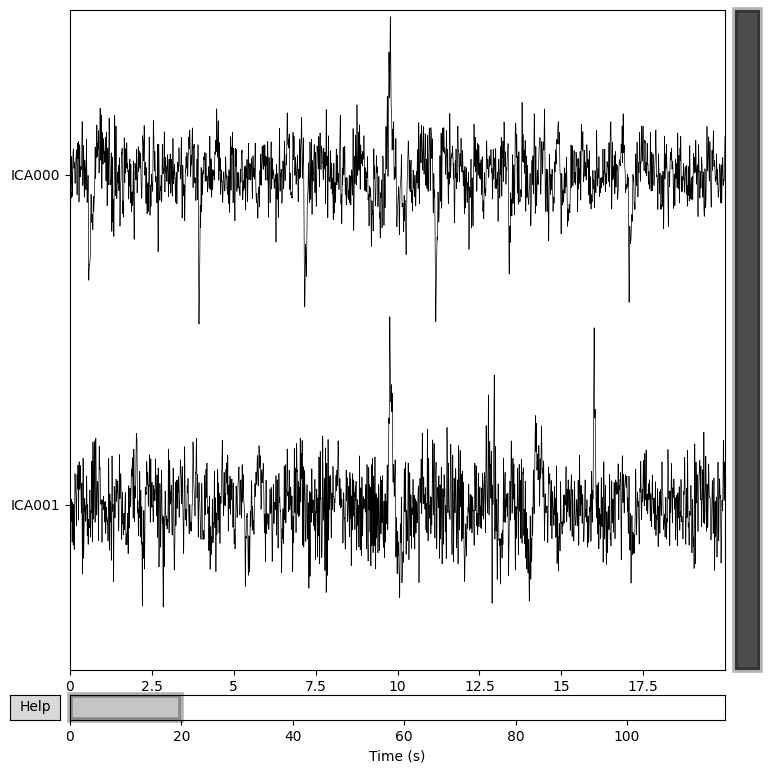

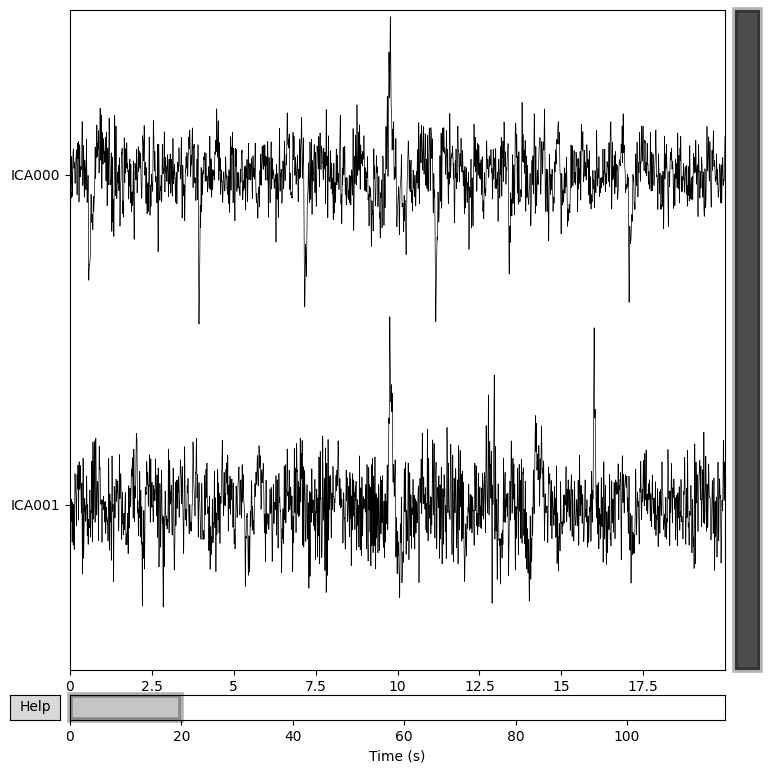

In [ ]:
ica.plot_sources(raw)

By inspection, let's select out the muscle-artifact components based on
:footcite:`DharmapraniEtAl2016` manually.

The criteria are:

- Positive slope of log-log power spectrum between 7 and 75 Hz
  (here just flat because it's not in log-log)
- Peripheral focus or dipole/multi-pole foci (the blue and red
  blobs in the topomap are far from the vertex where the most
  muscle is)
- Single focal point (low spatial smoothness; there is just one focus
  of the topomap compared to components like the first ones that are
  more likely neural which spread across the topomap)

The other attribute worth noting is that the time course in
:func:`mne.preprocessing.ICA.plot_sources` looks like EMG; you can
see spikes when each motor unit fires so that the time course looks fuzzy
and sometimes has large spikes that are often at regular intervals.

ICA component 13 is a textbook example of what muscle artifact looks like.
The focus of the topomap for this component is right on the temporalis
muscle near the ears. There is also a minimum in the power spectrum at around
10 Hz, then a maximum at around 25 Hz, generally resulting in a positive
slope in log-log units; this is a very typical pattern for muscle artifact.



Fitting ICA to data using 2 channels (please be patient, this may take a while)
Selecting by number: 2 components
Fitting ICA took 0.4s.
    Using multitaper spectrum estimation with 7 DPSS windows


/tmp/ipykernel_32500/2441267627.py:14: RuntimeWarning: Using n_components=2 (resulting in n_components_=2) may lead to an unstable mixing matrix estimation because the ratio between the largest (2) and smallest (1.8e-32) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 1
  ica.fit(raw_ica)


Not setting metadata
58 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
58 matching events found
No baseline correction applied
0 projection items activated


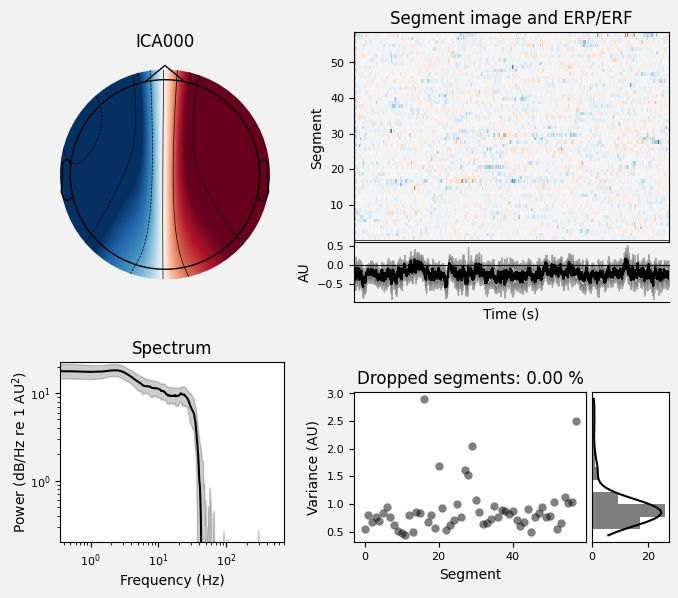

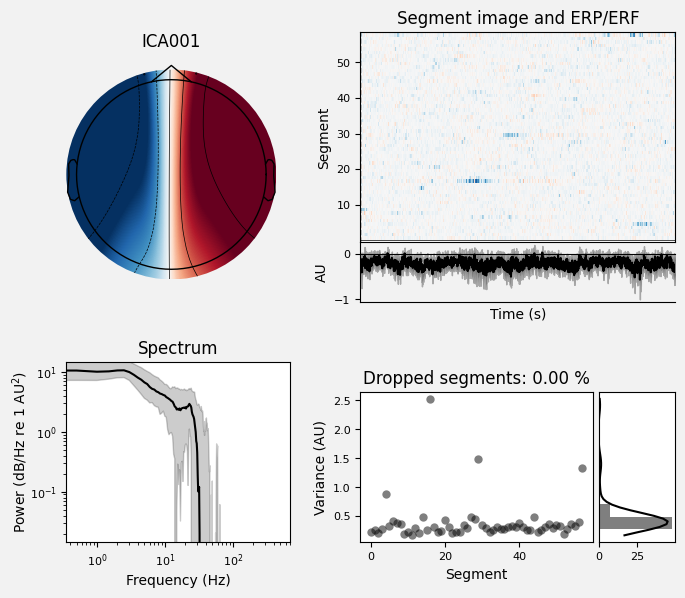

[<Figure size 700x600 with 6 Axes>, <Figure size 700x600 with 6 Axes>]

In [ ]:
# Crear un Raw solo con los canales reales
# ICA para realizar el analisis topografico trabaja con componentes que presentan valores, si intenta leer valores vacios o ceros falla
raw_ica = raw.copy().pick(["Fp1", "Fp2"])

# Ajustar la ICA sobre esos canales
from mne.preprocessing import ICA

ica = ICA(
    n_components=2,
    method="picard",
    random_state=97
)

ica.fit(raw_ica)

# Mostrar propiedades
ica.plot_properties(raw_ica, picks=[0, 1], log_scale=True)

In [ ]:
print(ch_names)

['Fp1', 'Fp2', 'EEG3', 'EEG4', 'EEG5', 'EEG6', 'EEG7', 'EEG8', 'EEG9', 'EEG10', 'EEG11', 'EEG12', 'EEG13', 'EEG14', 'EEG15', 'EEG16', 'EEG17', 'EEG18', 'EEG19', 'EEG20', 'EEG21', 'EEG22', 'EEG23', 'EEG24', 'EEG25', 'EEG26', 'EEG27', 'EEG28', 'EEG29', 'EEG30', 'EEG31', 'EEG32', 'EEG33', 'EEG34', 'EEG35', 'EEG36', 'EEG37', 'EEG38', 'EEG39', 'EEG40', 'EEG41', 'EEG42', 'EEG43', 'EEG44', 'EEG45', 'EEG46', 'EEG47', 'EEG48', 'EEG49', 'EEG50', 'EEG51', 'EEG52', 'EEG53', 'EEG54', 'EEG55', 'EEG56', 'EEG57', 'EEG58', 'EEG59', 'EEG60', 'EEG61', 'EEG62', 'EEG63', 'EEG64']


    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
58 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
58 matching events found
No baseline correction applied
0 projection items activated


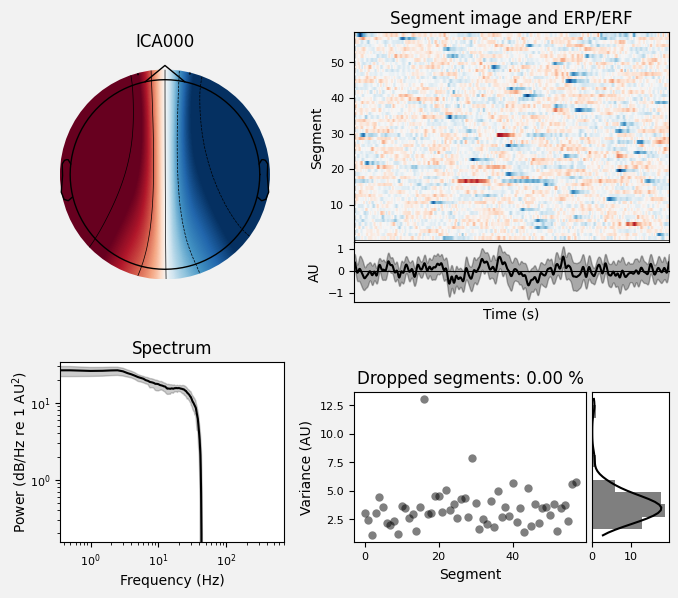

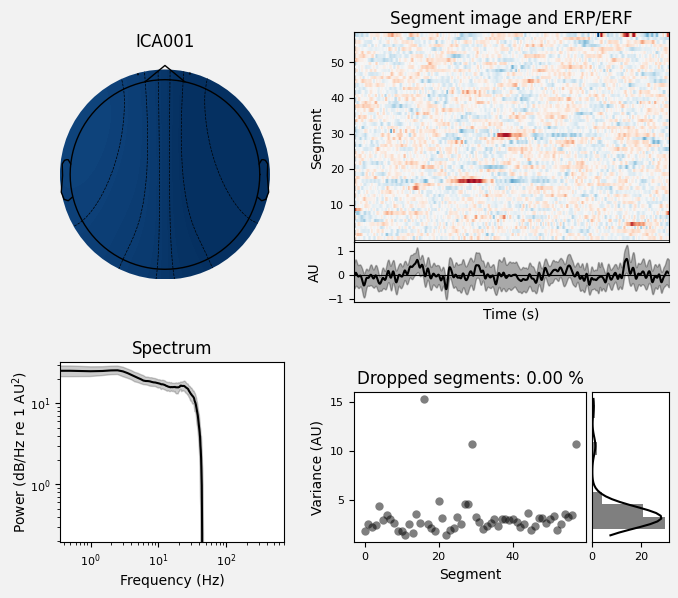

Applying ICA to Raw instance
    Transforming to ICA space (2 components)
    Zeroing out 1 ICA component
    Projecting back using 2 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (2 components)
    Zeroing out 2 ICA components
    Projecting back using 2 PCA components


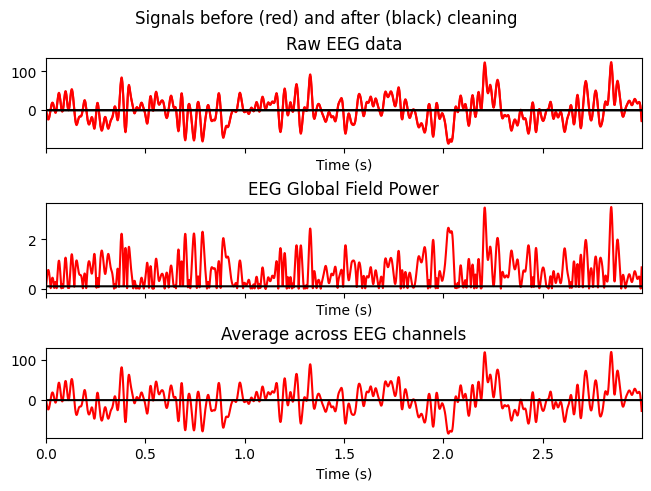

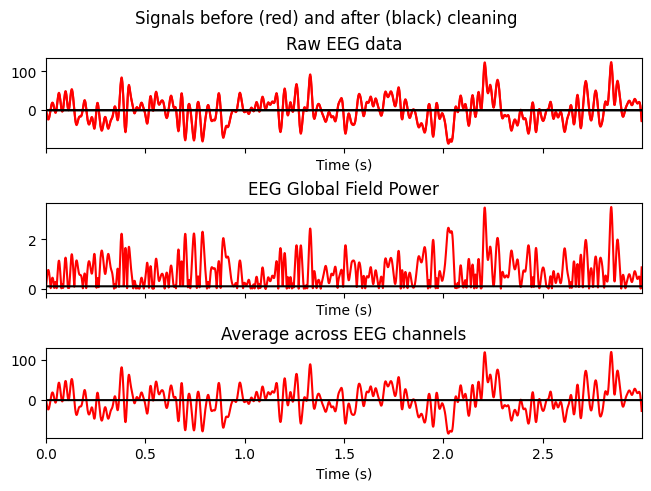

In [ ]:
muscle_idx = [0,1]
ica.plot_properties(raw, picks=muscle_idx, log_scale=True)

# first, remove blinks and heartbeat to compare
blink_idx = [0]
heartbeat_idx = [5]
ica.apply(raw, exclude=blink_idx + heartbeat_idx)
ica.plot_overlay(raw, exclude=muscle_idx)

Finally, let's try an automated algorithm to find muscle components
and ensure that it gets the same components we did manually.



Effective window size : 2.048 (s)


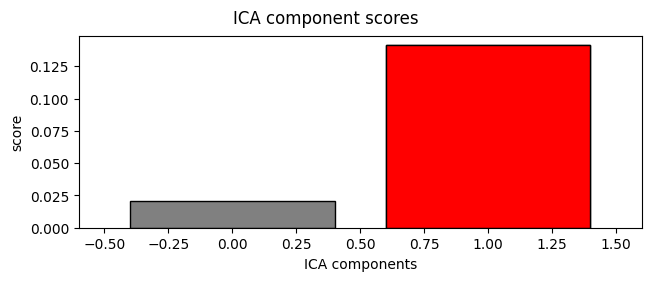

Manually found muscle artifact ICA components:      [0, 1]
Automatically found muscle artifact ICA components: [1]


In [ ]:
muscle_idx_auto, scores = ica.find_bads_muscle(raw)
ica.plot_scores(scores, exclude=muscle_idx_auto)
print(
    f"Manually found muscle artifact ICA components:      {muscle_idx}\n"
    f"Automatically found muscle artifact ICA components: {muscle_idx_auto}"
)

## References

Dhani Dharmaprani, Hoang K. Nguyen, Trent W. Lewis, Dylan DeLosAngeles, John O. Willoughby, and Kenneth J. Pope. A comparison of independent component analysis algorithms and measures to discriminate between EEG and artifact components. In 2016 38th Annual International Conference of the IEEE Engineering in Medicine and Biology Society (EMBC), 825–828. Orlando, FL, USA, 2016. IEEE. doi:10.1109/EMBC.2016.7590828.

